# Diffractive Recurrent Neural Network (D-RNN)

In this notebook, we implement the recurrent diffractive architecture proposed in [[1]](https://www.nature.com/articles/s41566-021-00796-w#Sec4) for human action recognition using [the Weizmann dataset](https://www.wisdom.weizmann.ac.il/~vision/SpaceTimeActions.html).

In [1]:
from svetlanna.units import ureg
import svetlanna as sv
import torch
import torch.nn as nn

import os
import numpy as np

from torchvision import transforms

import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from svetlanna.transforms import ToWavefront

from collections import defaultdict

# 1. Simulation Parameters

We use different model parameters than those specified in the article.

In [2]:
wavelength = 750 * ureg.um

c_const = 299_792_458 * ureg.m / ureg.s
frequency = c_const / wavelength
neuron_size = 400 * ureg.um

# Grid resolution
Nx = Ny = 128

# Physical dimensions of each diffractive layer
x_layer_size_m = Nx * neuron_size
y_layer_size_m = Ny * neuron_size

print(f'lambda    = {wavelength / ureg.um:.3f} um')
print(f'frequency = {frequency / ureg.THz:.3f} THz')
print(f'neuron size = {neuron_size * 1e6:.3f} um')
print(f'Layer size (in mm): {x_layer_size_m * 1e3 :.3f} x {y_layer_size_m * 1e3 :.3f}')

lambda    = 750.000 um
frequency = 0.400 THz
neuron size = 400.000 um
Layer size (in mm): 51.200 x 51.200


In [3]:
SIM_PARAMS = sv.SimulationParameters(
    {
        'W': torch.linspace(-x_layer_size_m / 2, x_layer_size_m / 2, Nx),
        'H': torch.linspace(-y_layer_size_m / 2, y_layer_size_m / 2, Ny),
        'wavelength': wavelength,
    }
)

# 2. Dataset Preparation

## 2.1. Load Data

> The extracted masks obtained by background subtraction: the file (Matlab 7 format, ~1700KB) contains both the original masks as well as the aligned ones (that were the actual inputs to our algorithm).

All masks are of the shape $64 \times 64$.

In [4]:
from requests import get
from scipy.io import loadmat
from skimage.transform import resize


ACTIONS = [
    'bend', 'jack', 'jump', 'pjump', 'run', 'side', 'skip', 'walk', 'wave1', 'wave2'
]
ID_TO_ACTION = {idx: act for idx, act in enumerate(ACTIONS)}
ACTION_TO_ID = {act: idx for idx, act in enumerate(ACTIONS)}


def download_weizmann_masks(dest='./weizmann'):
    """Downloads and preprocesses masks for Weizmann human action dataset."""
    os.makedirs(dest, exist_ok=True)
    
    # Download classification_masks.mat
    mat_path = os.path.join(dest, 'classification_masks.mat')
    if not os.path.exists(mat_path):
        print("Downloading masks...", end=' ')
        url = 'http://www.wisdom.weizmann.ac.il/~vision/VideoAnalysis/Demos/SpaceTimeActions/DB/classification_masks.mat'
        with open(mat_path, 'wb') as f:
            f.write(get(url).content)
        print('Done!')
    
    masks = loadmat(mat_path)['original_masks'][0, 0]
    
    # Process and save masks for each action
    for act in ACTIONS:
        act_dir = os.path.join(dest, f'{act}_masks')
        os.makedirs(act_dir, exist_ok=True)
        print(f"Saving masks for `{act}`...", end=' ')
        
        for person in ['daria', 'denis', 'eli', 'ido', 'ira', 'lena', 'lyova', 'moshe', 'shahar']:
            vid_key = f'{person}_{act}'
            # Handle duplicate videos
            if person == 'lena' and act in ['walk', 'run', 'skip']:
                vid_key += '1'
            
            npy_path = os.path.join(act_dir, f'{person}_{act}.npy')
            if os.path.exists(npy_path):
                continue
            
            try:
                mask = np.array(masks[vid_key], dtype=np.float64)
            except (ValueError, KeyError):
                continue
            
            # Crop to square, transpose (H,W,T)->(T,H,W), resize to 64x64, add channel dim
            h, w = mask.shape[:2]
            s = min(h, w)
            x0, y0 = (w - s) // 2, (h - s) // 2
            mask = mask[y0:y0+s, x0:x0+s, :]
            mask = np.transpose(mask, (2, 0, 1))
            mask = np.stack([resize(mask[t], (64, 64)) for t in range(mask.shape[0])], axis=0)
            mask = mask[:, np.newaxis, :, :]
            
            np.save(npy_path, mask)
        
        print('Done!')

In [5]:
download_weizmann_masks(dest="data/weizmann")

Saving masks for `bend`... Done!
Saving masks for `jack`... Done!
Saving masks for `jump`... Done!
Saving masks for `pjump`... Done!
Saving masks for `run`... Done!
Saving masks for `side`... Done!
Saving masks for `skip`... Done!
Saving masks for `walk`... Done!
Saving masks for `wave1`... Done!
Saving masks for `wave2`... Done!


## 2.2. Train and Test Data Split

Citations from methods of [[1]](https://www.nature.com/articles/s41566-021-00796-w#Sec4):

> We adopted the actions from six subjects ($60$ video sequences) as the training set, with the rest of the actions, that is, three subjects ($30$ video sequences), as the test set.

In [6]:
# Select 6 videos of each action for training (60% train, 40% test)
np.random.seed(78)
seed_for_each_action = np.random.randint(
    low=0, high=100, 
    size=len(ACTIONS), 
)
n_files_of_each_action = 9
n_train = 6

all_files = []
all_train_files = []  # Training dataset files
all_test_files = []   # Testing dataset files


rng = np.random.default_rng(78)

for ind, act_this in enumerate(ACTIONS):
    dir_this = f'data/weizmann/{act_this}_masks'
    lisdir_this = [fn for fn in os.listdir(dir_this) if fn[-3:] == 'npy']
    
    train_ids = rng.choice(n_files_of_each_action, n_train, replace=False)
    
    for ind_file, filepath in enumerate(lisdir_this):
        all_files.append(f'{dir_this}/{filepath}')
        
        if ind_file in train_ids:
            all_train_files.append(f'{dir_this}/{filepath}')
        else:
            all_test_files.append(f'{dir_this}/{filepath}')

In [7]:
print(f'Train files: {len(all_train_files)}')
print(f'Test  files: {len(all_test_files)}')

Train files: 60
Test  files: 30


In [8]:
print(f'All files: {len(all_files)}')

All files: 90


## 2.3. Dataset Creation and Preprocessing

Citations from methods of [[1]](https://www.nature.com/articles/s41566-021-00796-w#Sec4):

> ... each video was divided into numbers of sub-sequences by sequentially extracting three frames for each sub-sequence with a frame interval of two.

### Preprocessing Pipeline

Each frame undergoes the following preprocessing steps:

1. **Silhouette extraction**: Detect and crop the bounding box containing the human silhouette
2. **Centering**: Center the extracted silhouette on a 64×64 pixel canvas
3. **Resizing**: Interpolate to the simulation grid size `(Ny, Nx)` 
4. **Vertical flip**: Flip vertically so that `y[0]` corresponds to the bottom of the wavefront
5. **Wavefront conversion**: Transform to wavefront representation with amplitude modulation

In [9]:
# Sequence parameters: 3 frames per sequence with 2-frame intervals
NETWORK_SEQ = 3
SKIP = 2 

In [10]:
class WeizmannDsWfSeqs(Dataset):
    def __init__(
        self,
        ds_filepathes,
        transformations: transforms.Compose,
    ):
        self.ds_filepathes = ds_filepathes

        # Load all masks and extract silhouette coordinates
        self.all_np_masks, self.files_silhouettes_coord = self.load_masks()
        self.ds_constructor = self.get_ds_constructor()
        self.transformations = transformations

    def load_masks(self):
        """
        Load all masks by filepathes and returns two dictionaries
            1. {filepath: video masks}
            3. {filepath: list (len = number of timesteps in a file) of tuples;
                          each tuple: (ul_corner_y, ul_corner_x, lr_corner_y, lr_corner_x)}
        """
        all_np_masks = {}
        files_silhouette_bounds = defaultdict(list)

        for filepath in self.ds_filepathes:
            mask = np.load(filepath)
            all_np_masks[filepath] = mask

            # Find bounding box for silhouette at each timestep
            for ind_frame in range(mask.shape[0]):
                frame_this = all_np_masks[filepath][ind_frame, 0, :, :]

                strickt_silhouette = torch.where(
                    torch.tensor(frame_this) > 0.05, 1.0, 0.0
                )

                if strickt_silhouette.sum() > 0:
                    # Find indices where silhouette is present
                    y_ids = torch.where(strickt_silhouette.sum(dim=1) > 0)[0]  # Y direction
                    x_ids = torch.where(strickt_silhouette.sum(dim=0) > 0)[0]  # X direction

                    coordinates_this = (
                        y_ids[0].item(),
                        x_ids[0].item(),
                        y_ids[-1].item(),
                        x_ids[-1].item(),
                    )
                else:  # no silhouette (is it possible?)
                    coordinates_this = (0, 1, 0, 1)

                files_silhouette_bounds[filepath].append(coordinates_this)

        return all_np_masks, files_silhouette_bounds

    def get_ds_constructor(self):
        """
        Returns a list of tuples (file_index, frame_indices) for valid sequences.
        Each sequence contains NETWORK_SEQ frames with SKIP frame intervals.
        """
        ds_constructor = []

        for filepath in self.ds_filepathes:
            timesteps_this = self.all_np_masks[filepath].shape[0]

            for ind_timestep in range(timesteps_this):
                seq_this = [ind_timestep]

                # Build sequence with frame skipping
                ind_current = ind_timestep
                for _ in range(1, NETWORK_SEQ):
                    ind_current += SKIP + 1
                    if ind_current < timesteps_this:
                        seq_this.append(ind_current)
                    else:
                        break

                # Only add complete sequences
                if len(seq_this) == NETWORK_SEQ:
                    ds_constructor.append((filepath, seq_this))

        return ds_constructor

    def silhouette_only(self, filepath, frame_ind):
        """
        Returns centered silhouettes for frame number `frame_ind` of `filepath` video.
        # Extract silhouette bounding box coordinates
        """
        # silhouette box coordinates
        upper_left_y, upper_left_x, lower_right_y, lower_right_x = (
            self.files_silhouettes_coord[filepath][frame_ind]
        )

        silhouette_this = torch.tensor(
            self.all_np_masks[filepath][
                frame_ind,
                0,
                upper_left_y : lower_right_y + 1,
                upper_left_x : lower_right_x + 1,
            ]
        )  # size equal to bounding box size!

        return silhouette_this.unsqueeze(0)

    def __len__(self):
        return len(self.ds_constructor)

    def __getitem__(self, ind: int) -> tuple:
        """
        Returns wavefront and label.
        """

        filepath, frames_ids = self.ds_constructor[ind]
        # Extract action name from filepath
        action_name = filepath.split("/")[-2].split("_")[0]
        label = ACTION_TO_ID[action_name]

        sequence_raw = [
            self.silhouette_only(filepath, frame_ind) for frame_ind in frames_ids
        ]

        # apply transformations
        sequence_wavefronts = torch.stack(
            [self.transformations(frame) for frame in sequence_raw], dim=0
        )

        return sequence_wavefronts, label

In [11]:
# Define transformations for preprocessing silhouettes
transforms_for_ds = transforms.Compose(
    [
        transforms.CenterCrop(64),  # Crop to standard size
        transforms.Resize(size=SIM_PARAMS.axes_size(axs=('y', 'x'))),  # Resize to simulation grid
        transforms.functional.vflip,  # Flip vertically for proper orientation
        ToWavefront(modulation_type='amp')  # Convert to wavefront with amplitude modulation
    ]  
)

# Create training and testing datasets
train_seqs_ds = WeizmannDsWfSeqs(
    all_train_files,
    transforms_for_ds,
)

test_seqs_ds = WeizmannDsWfSeqs(
    all_test_files,
    transforms_for_ds,
)

print(f'Train dataset of sequences: {len(train_seqs_ds)}')
print(f'Test  dataset of sequences: {len(test_seqs_ds)}')

Train dataset of sequences: 3312
Test  dataset of sequences: 1680


## 2.4. Detector Masks for Classification

> The number of output regions was set to be the same as the number of categories, that is, ten regions for the MNIST, Fashion-MNIST and Weizmann databases, and six regions for the KTH database, each with a width of $0.46$ mm.

We create detector masks to integrate the optical field intensity over each detector region.

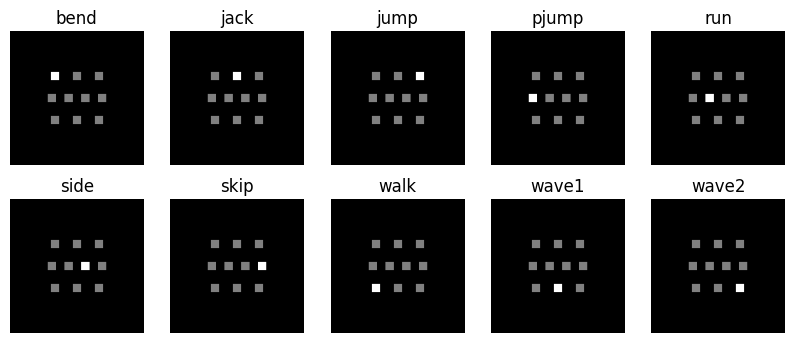

In [12]:
def create_segment_mask(x: int, y: int):
    """Create a detector mask at specified position (x, y). Each detector has size 4.4λ × 4.4λ."""
    dx = dy = int(4.4 * wavelength / neuron_size)

    res = torch.zeros((Nx, Ny))
    res[
        (Ny - dy) // 2 + y : (Ny + dy) // 2 + y, (Nx - dx) // 2 + x : (Nx + dx) // 2 + x
    ] = 1.0
    return res


d = int(4.4 * wavelength / neuron_size)

# Create 10 detector masks arranged in a specific pattern
detector_segment_masks = torch.stack(
    [
        create_segment_mask(-int(2.7 * d), -int(2.7 * d)),  # Detector for action 0
        create_segment_mask(0, -int(2.7 * d)),              # Detector for action 1
        create_segment_mask(int(2.7 * d), -int(2.7 * d)),   # Detector for action 2
        create_segment_mask(-int(3 * d), 0),                # Detector for action 3
        create_segment_mask(-int(1 * d), 0),                # Detector for action 4
        create_segment_mask(int(1 * d), 0),                 # Detector for action 5
        create_segment_mask(int(3 * d), 0),                 # Detector for action 6
        create_segment_mask(-int(2.7 * d), int(2.7 * d)),   # Detector for action 7
        create_segment_mask(0, int(2.7 * d)),               # Detector for action 8
        create_segment_mask(int(2.7 * d), int(2.7 * d)),    # Detector for action 9
    ],
    dim=-1,
)

# Visualize the detector layout
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(
        detector_segment_masks[..., i] + torch.sum(detector_segment_masks, axis=-1),
        cmap="gray",
    )
    plt.title(f"{ID_TO_ACTION[i]}")
    plt.gca().set_axis_off()
plt.show()

## 2.5. Examples from Training Dataset

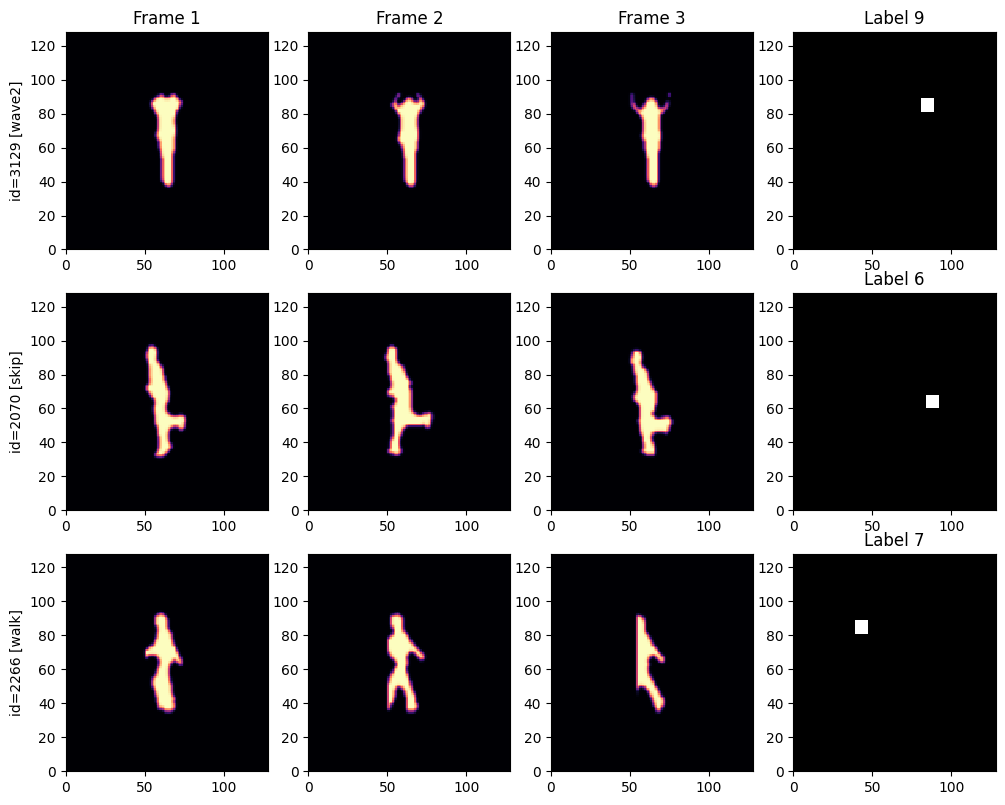

In [13]:
n_examples = 3
rng = np.random.default_rng(7)
train_examples_ids = rng.choice(range(len(train_seqs_ds)), n_examples)

n_cols = NETWORK_SEQ + 1  # Frames + target detector

fig, axs = plt.subplots(n_examples, n_cols, figsize=(n_cols * 3, n_examples * 3.2))

for ind_ex, ind_train in enumerate(train_examples_ids):
    sequence, label = train_seqs_ds[ind_train]
    
    # Plot each frame in the sequence
    for frame_ind in range(NETWORK_SEQ):
        frame_this_wf = sequence[frame_ind]
        
        if ind_ex == 0:
            axs[ind_ex][frame_ind].set_title(f'Frame {frame_ind + 1}')

        if frame_ind == 0:
            axs[ind_ex][frame_ind].set_ylabel(f'id={ind_train} [{ID_TO_ACTION[label]}]')

        axs[ind_ex][frame_ind].pcolormesh(
            frame_this_wf.intensity, cmap="magma",
            vmin=0, vmax=1, 
        )
    
    # Plot target detector mask
    axs[ind_ex][frame_ind + 1].set_title(f'Label {label}')
    axs[ind_ex][frame_ind + 1].pcolormesh(detector_segment_masks[..., label], cmap="grey")
    
plt.show()

# 3. Diffractive Recurrent Neural Network

Fig. 4(a) from [[1]](https://www.nature.com/articles/s41566-021-00796-w#Sec4).

> For the D-RNN hidden layer at the time step of $t$, the hidden state $h_t$ is a function of the hidden state $h_{t−1}$ at the time step of $t−1$ and of the input sequence $x_t$ at the time step of $t$.
We adopt an affine combination to fuse the states from these two sources, that is, $h_t=\lambda f_1(h_{t-1})+(1-\lambda)f_2(x_t)$, where $m_t=f_1(h_{t-1})$ denotes the memory state mapping from $h_{t-1}$; $i_t=f_2(x_t)$ denotes the input state mapping from $x_t$; and $\lambda\in(0,1)$ is the fusing coefficient that controls the strength of the memory state with respect to the input state.

In this implementation, the read-in layer ($f_2$), memory layer ($f_1$), and read-out layer each consist of a diffractive layer followed by free space propagation. Additionally, free space is applied before the read-out layer.

In [14]:
# Distance of free spaces in the setup
DISTANCE = 100 * wavelength 

In [15]:
class DiffractiveRNN(torch.nn.Module):
    """
    A recurrent diffractive network proposed in [1].
    """

    def __init__(
        self,
        sequence_size: int,
        fusing_coeff: float,
        sim_params: sv.SimulationParameters,
    ):
        """
        Parameters:
        -----------
        sequence_size : int
            Number of frames in each sub-sequence for action prediction.
        fusing_coeff : float
            Fusing coefficient (lambda) that controls the balance between memory and input states.
        sim_params : SimulationParameters
            Simulation parameters for the optical system.
        """
        super().__init__()

        self.sequence_len = sequence_size
        self.fusing_coeff = fusing_coeff
        self.sim_params = sim_params

        self.free_space_optimal = sv.elements.FreeSpace(
            self.sim_params,
            DISTANCE,
            method="AS",
        )

        self.read_in_layer = sv.LinearOpticalSetup((
            sv.elements.DiffractiveLayer(
                self.sim_params,
                mask=sv.ConstrainedParameter(
                    torch.pi * torch.ones(self.sim_params.axes_size(("y", "x"))),
                    0, 2 * torch.pi,
                )
            ),
            sv.elements.FreeSpace(self.sim_params, DISTANCE, method="AS"),
        ))
        self.memory_layer = sv.LinearOpticalSetup((
            sv.elements.DiffractiveLayer(
                self.sim_params,
                mask=sv.ConstrainedParameter(
                    torch.pi * torch.ones(self.sim_params.axes_size(("y", "x"))),
                    0, 2 * torch.pi,
                )
            ),
            sv.elements.FreeSpace(self.sim_params, DISTANCE, method="AS"),
        ))
        self.read_out_layer = sv.LinearOpticalSetup((
            sv.elements.DiffractiveLayer(
                self.sim_params,
                mask=sv.ConstrainedParameter(
                    torch.pi * torch.ones(self.sim_params.axes_size(("y", "x"))),
                    0, 2 * torch.pi,
                )
            ),
            sv.elements.FreeSpace(self.sim_params, DISTANCE, method="AS"),
        ))

    def wf_forward(self, subsequence_wf):
        """Process sequence through RNN layers and return output wavefront."""
        h_prev = None
        for frame_ind in range(self.sequence_len):
            x_t = subsequence_wf[..., frame_ind, :, :]

            i_t = self.read_in_layer(x_t)  # Input state: f_2(x_t)

            if h_prev is not None:
                m_t = self.memory_layer(h_prev)  # Memory state: f_1(h_{t-1})
            else:
                m_t = 0

            # Combine memory and input states: h_t = λ*f_1(h_{t-1}) + (1-λ)*f_2(x_t)
            h_prev = self.fusing_coeff * m_t + (1 - self.fusing_coeff) * i_t
            h_prev = self.free_space_optimal(h_prev)

        return self.read_out_layer(h_prev)
    
    def forward(self, subsequence_wf):
        """Forward pass returning intensity at each detector for classification."""
        out = self.wf_forward(subsequence_wf)
        intensity = out.intensity

        # Calculate total intensity at each detector region
        I_l = (intensity[..., None] * detector_segment_masks).sum(dim=(-2, -3))

        return I_l

In [16]:
# Initialize the diffractive RNN model
model = DiffractiveRNN(
    sequence_size=NETWORK_SEQ,
    fusing_coeff=0.5,
    sim_params=SIM_PARAMS,
)

# 4. Model Training

## 4.1. Training Preparation

In [17]:
# Create data loaders for training and testing
batch_size = 10
train_dataloader = torch.utils.data.DataLoader(
    train_seqs_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
)

test_dataloader = torch.utils.data.DataLoader(
    test_seqs_ds,
    batch_size=20,
    shuffle=True,
    drop_last=False,
)

In [18]:
# Configure optimizer and loss function
optimizer = torch.optim.Adam(params=model.parameters(), lr=5e-3)
loss_fn = nn.CrossEntropyLoss()

## 4.2. Training and Evaluation Loops

The training loops are direct copy of those presented at torch [documentation](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html).

In [19]:
def train_loop(dataloader, model, loss_fn, optimizer):
    """Train the model for one epoch."""
    size = len(dataloader.dataset)
    model.train()
    
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Print progress every 100 batches
        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    """Evaluate the model on test data."""
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(
        f"Test Error: \n Accuracy: {(100 * correct):>0.1f}%, Avg loss: {test_loss:>8f} \n"
    )
    return correct, test_loss

In [20]:
# Track training progress
test_accuracies = []
test_losses = []

# Evaluate untrained model
accuracy, loss = test_loop(test_dataloader, model, loss_fn)
test_accuracies.append(accuracy)
test_losses.append(loss)

# Train the model
epochs = 4
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    accuracy, loss = test_loop(test_dataloader, model, loss_fn)
    test_accuracies.append(accuracy)
    test_losses.append(loss)

print("Done!")

Test Error: 
 Accuracy: 5.2%, Avg loss: 2.585684 

Epoch 1
-------------------------------
loss: 2.912702  [   10/ 3312]
loss: 2.246254  [ 1010/ 3312]
loss: 1.471360  [ 2010/ 3312]
loss: 0.789750  [ 3010/ 3312]
Test Error: 
 Accuracy: 64.8%, Avg loss: 1.199670 

Epoch 2
-------------------------------
loss: 0.845862  [   10/ 3312]
loss: 0.933215  [ 1010/ 3312]
loss: 0.604818  [ 2010/ 3312]
loss: 0.338716  [ 3010/ 3312]
Test Error: 
 Accuracy: 77.1%, Avg loss: 0.884606 

Epoch 3
-------------------------------
loss: 0.893411  [   10/ 3312]
loss: 0.370726  [ 1010/ 3312]
loss: 0.574830  [ 2010/ 3312]
loss: 0.629249  [ 3010/ 3312]
Test Error: 
 Accuracy: 81.4%, Avg loss: 0.746028 

Epoch 4
-------------------------------
loss: 0.319646  [   10/ 3312]
loss: 0.354499  [ 1010/ 3312]
loss: 0.414156  [ 2010/ 3312]
loss: 0.386006  [ 3010/ 3312]
Test Error: 
 Accuracy: 79.8%, Avg loss: 0.714293 

Done!


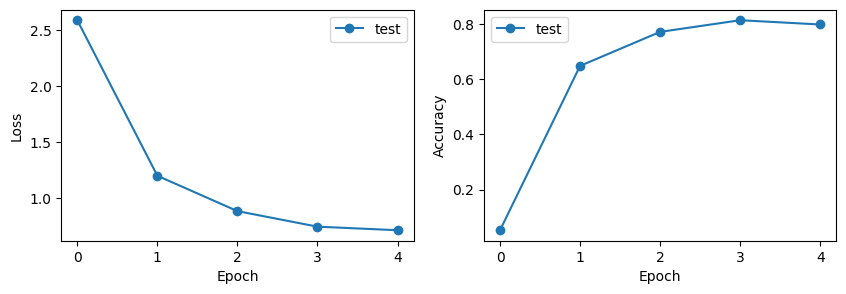

In [21]:
# Visualize training progress
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

axs[0].plot(range(epochs + 1), test_losses, "-o", label="test")
axs[0].set_ylabel("Loss")
axs[0].set_xlabel("Epoch")
axs[0].legend()

axs[1].plot(range(epochs + 1), test_accuracies, "-o", label="test")
axs[1].set_ylabel("Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].legend()

plt.show()

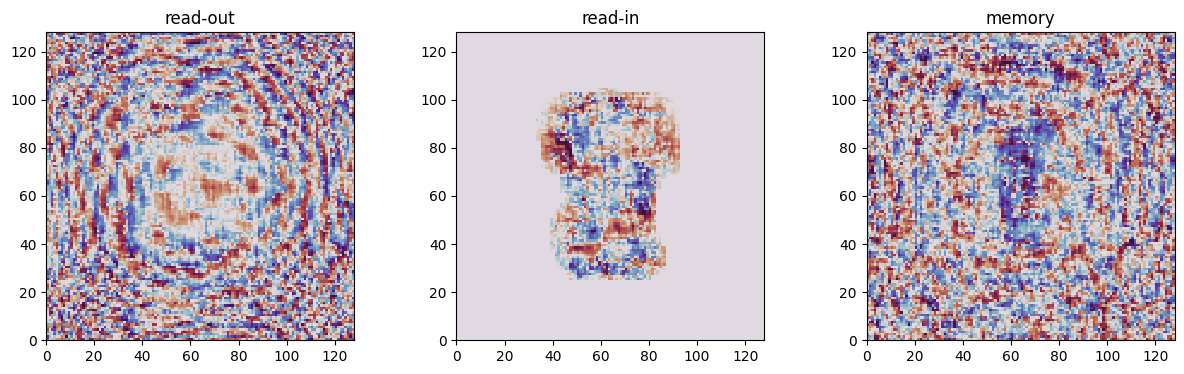

In [22]:
# Visualize trained phase masks from all diffractive layers
diffractive_layers = {
    "read-out": model.read_out_layer.elements[0],
    "read-in": model.read_in_layer.elements[0],
    "memory": model.memory_layer.elements[0],
}

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for ind_layer, (layer_name, layer) in enumerate(diffractive_layers.items()):
    plt.subplot(1, 3, ind_layer + 1)
    trained_mask = layer.mask.detach()

    plt.pcolormesh(trained_mask, cmap="twilight_shifted")
    plt.title(layer_name)
    plt.gca().set_aspect('equal')
plt.show()

# 5. Results Visualization

## 5.1. Classification Examples

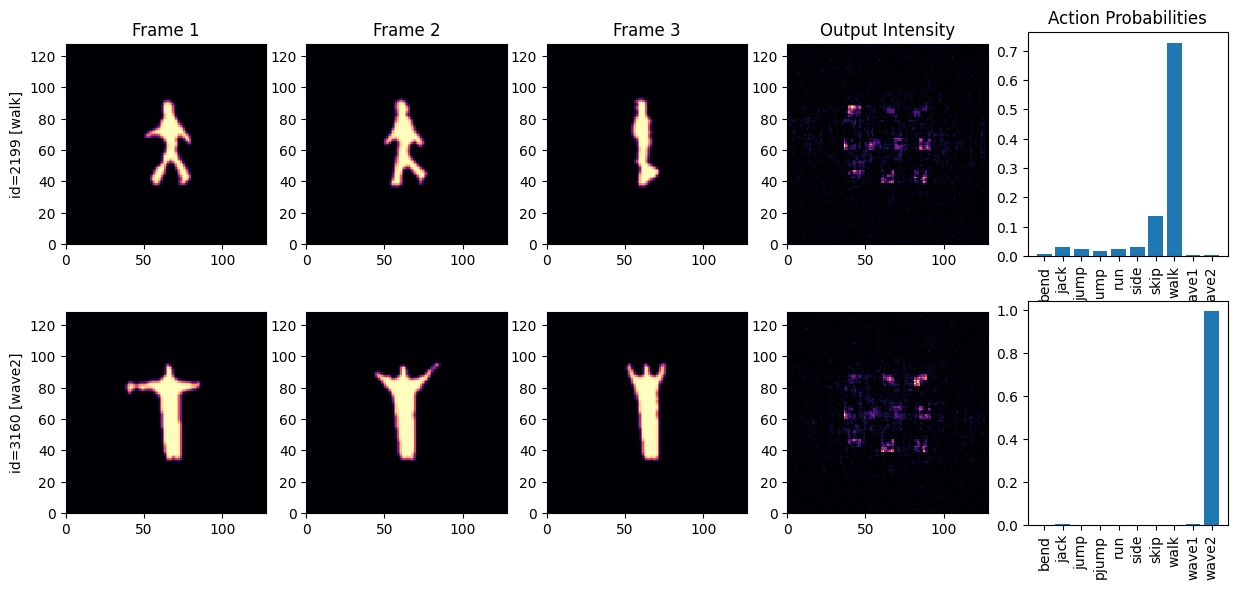

In [23]:
n_examples = 2
rng = np.random.default_rng(41)
train_examples_ids = rng.choice(range(len(train_seqs_ds)), n_examples)

n_cols = NETWORK_SEQ + 2  # Frames + output intensity + probabilities

fig, axs = plt.subplots(n_examples, n_cols, figsize=(n_cols * 3, n_examples * 3.2))

for ind_ex, ind_train in enumerate(train_examples_ids):
    sequence, label = train_seqs_ds[ind_train]
    
    # Plot input frames
    for frame_ind in range(NETWORK_SEQ):
        frame_this_wf = sequence[frame_ind]
        
        if ind_ex == 0:
            axs[ind_ex][frame_ind].set_title(f'Frame {frame_ind + 1}')

        if frame_ind == 0:
            axs[ind_ex][frame_ind].set_ylabel(f'id={ind_train} [{ID_TO_ACTION[label]}]')

        axs[ind_ex][frame_ind].pcolormesh(
            frame_this_wf.intensity, cmap="magma",
            vmin=0, vmax=1, 
        )
        axs[ind_ex][frame_ind].set_aspect('equal')
        
    # Generate and plot model predictions
    with torch.no_grad():
        out = model.wf_forward(sequence)
        out_probs = torch.softmax(model(sequence), -1)

    axs[ind_ex][frame_ind + 1].pcolormesh(out.intensity, cmap="magma")
    axs[ind_ex][frame_ind + 1].set_aspect('equal')
    if ind_ex == 0:
        axs[ind_ex][frame_ind + 1].set_title('Output Intensity')

    # Plot action classification probabilities
    axs[ind_ex][frame_ind + 2].bar(ACTIONS, out_probs)
    axs[ind_ex][frame_ind + 2].set_xticks(ACTIONS, ACTIONS, rotation='vertical')
    if ind_ex == 0:
        axs[ind_ex][frame_ind + 2].set_title('Action Probabilities')

plt.show()